# Clasificación de Imágenes de Frutas usando k-NN
## Tarea: Clasificación basada en extracción de características

### 1. Importar librerías necesarias

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from skimage.feature import hog
from skimage import exposure
import pandas as pd

### 2. Definir el path del dataset y las clases a clasificar

In [8]:
# Paths relativos desde la carpeta Code
dataset_path = os.path.join('..', 'DATA')
train_dir = os.path.join('..', 'Dataset', 'train')
test_dir = os.path.join('..', 'Dataset', 'test')

# Clases a clasificar (puedes agregar más clases si deseas)
clases = ['apple', 'banana']

print(f"Clases seleccionadas: {clases}")
print(f"Número de clases: {len(clases)}")
print(f"\nPaths configurados:")
print(f"  Dataset original: {os.path.abspath(dataset_path)}")
print(f"  Train: {os.path.abspath(train_dir)}")
print(f"  Test: {os.path.abspath(test_dir)}")

Clases seleccionadas: ['apple', 'banana']
Número de clases: 2

Paths configurados:
  Dataset original: c:\Users\cabarca2\MAESTRIA_IA\Visión-por-computador\semana1\DEBER\DATA
  Train: c:\Users\cabarca2\MAESTRIA_IA\Visión-por-computador\semana1\DEBER\Dataset\train
  Test: c:\Users\cabarca2\MAESTRIA_IA\Visión-por-computador\semana1\DEBER\Dataset\test


### 3. Cargar y visualizar 5 ejemplos de cada clase

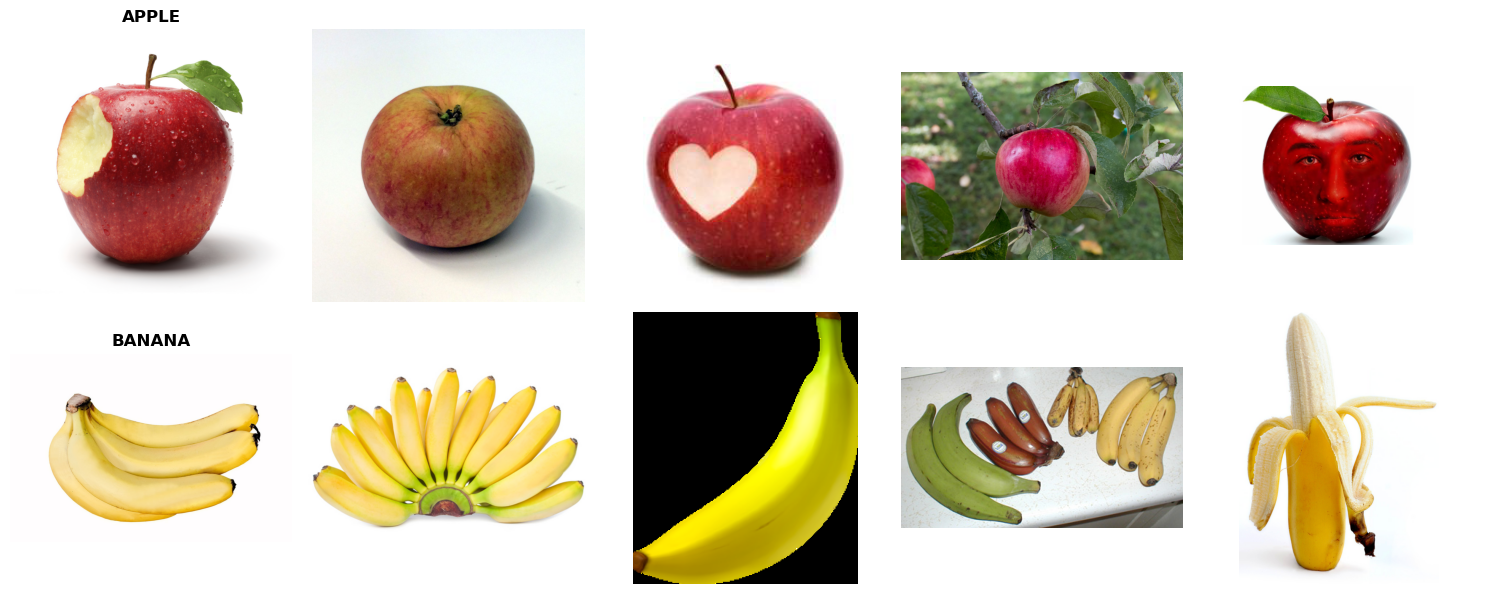

In [9]:
# Función para cargar imágenes de una clase
def cargar_imagenes_clase(clase, num_imagenes=5):
    clase_path = os.path.join(dataset_path, clase)
    imagenes_files = [f for f in os.listdir(clase_path) if f.endswith(('.jpg', '.jpeg', '.png', '.JPG'))]
    imagenes = []
    
    for i in range(min(num_imagenes, len(imagenes_files))):
        img_path = os.path.join(clase_path, imagenes_files[i])
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imagenes.append(img_rgb)
    
    return imagenes

# Visualizar 5 ejemplos de cada clase
fig, axes = plt.subplots(len(clases), 5, figsize=(15, len(clases)*3))

for idx, clase in enumerate(clases):
    imagenes = cargar_imagenes_clase(clase, num_imagenes=5)
    
    for i, img in enumerate(imagenes):
        if len(clases) > 1:
            axes[idx, i].imshow(img)
            axes[idx, i].axis('off')
            if i == 0:
                axes[idx, i].set_title(f'{clase.upper()}', fontsize=12, fontweight='bold')
        else:
            axes[i].imshow(img)
            axes[i].axis('off')
            if i == 0:
                axes[i].set_title(f'{clase.upper()}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 4. Cargar todas las imágenes del dataset

In [11]:
# Función para cargar todas las imágenes y sus etiquetas
def cargar_dataset(clases, dataset_path, target_size=(128, 128)):
    imagenes = []
    etiquetas = []
    rutas_imagenes = []  # Guardar rutas para poder copiarlas después
    
    for idx, clase in enumerate(clases):
        clase_path = os.path.join(dataset_path, clase)
        imagenes_files = [f for f in os.listdir(clase_path) if f.endswith(('.jpg', '.jpeg', '.png', '.JPG'))]
        
        print(f"Cargando clase '{clase}': {len(imagenes_files)} imágenes")
        
        for img_file in imagenes_files:
            img_path = os.path.join(clase_path, img_file)
            img = cv2.imread(img_path)
            
            if img is not None:
                # Redimensionar la imagen a un tamaño fijo
                img_resized = cv2.resize(img, target_size)
                imagenes.append(img_resized)
                etiquetas.append(idx)
                rutas_imagenes.append(img_path)
    
    return np.array(imagenes), np.array(etiquetas), rutas_imagenes

# Cargar el dataset completo
X_imagenes, y_etiquetas, rutas_imagenes = cargar_dataset(clases, dataset_path)

print(f"\nTotal de imágenes cargadas: {len(X_imagenes)}")
print(f"Forma de cada imagen: {X_imagenes[0].shape}")
print(f"Distribución de clases:")
for idx, clase in enumerate(clases):
    count = np.sum(y_etiquetas == idx)
    print(f"  {clase}: {count} imágenes")

Cargando clase 'apple': 68 imágenes
Cargando clase 'banana': 75 imágenes

Total de imágenes cargadas: 143
Forma de cada imagen: (128, 128, 3)
Distribución de clases:
  apple: 68 imágenes
  banana: 75 imágenes


### 5. Extraer características usando HOG (Histogram of Oriented Gradients)

In [12]:
# Función para extraer características HOG de una imagen
def extraer_caracteristicas_hog(imagen):
    # Convertir a escala de grises
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # Extraer HOG features
    features, hog_image = hog(gray, 
                              orientations=9, 
                              pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), 
                              visualize=True,
                              block_norm='L2-Hys')
    
    return features

# Extraer características de todas las imágenes
print("Extrayendo características HOG de todas las imágenes...")
X_features = []

for img in X_imagenes:
    features = extraer_caracteristicas_hog(img)
    X_features.append(features)

X_features = np.array(X_features)

print(f"Características extraídas: {X_features.shape}")
print(f"Cada imagen tiene {X_features.shape[1]} características")

Extrayendo características HOG de todas las imágenes...
Características extraídas: (143, 8100)
Cada imagen tiene 8100 características


### 6. Visualizar ejemplo de extracción HOG

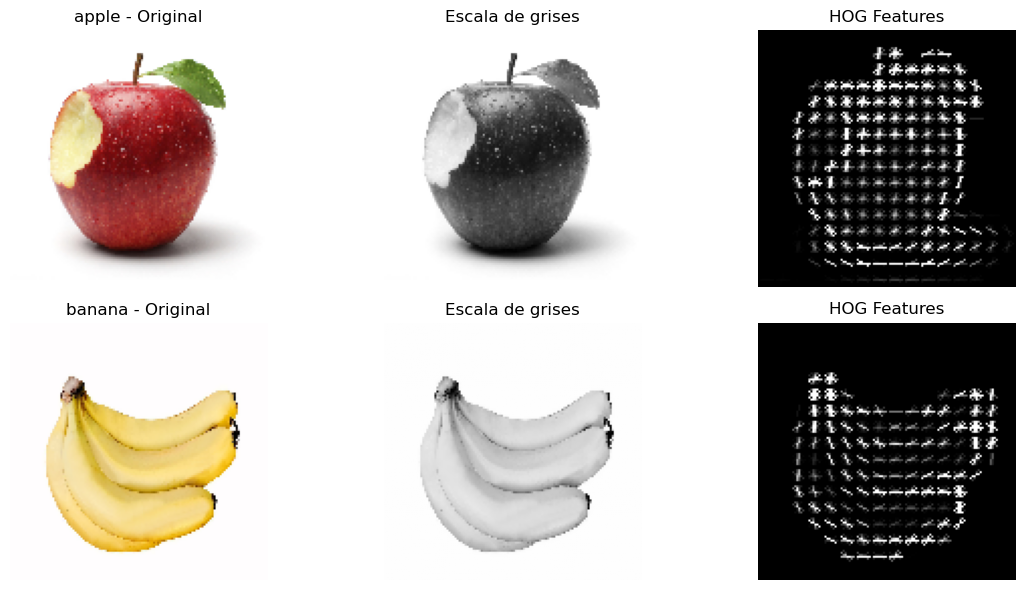

In [13]:
# Visualizar HOG para una imagen de cada clase
fig, axes = plt.subplots(len(clases), 3, figsize=(12, len(clases)*3))

for idx, clase in enumerate(clases):
    # Obtener una imagen de la clase
    clase_idx = np.where(y_etiquetas == idx)[0][0]
    img = X_imagenes[clase_idx]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Extraer HOG con visualización
    features, hog_image = hog(gray, 
                              orientations=9, 
                              pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), 
                              visualize=True,
                              block_norm='L2-Hys')
    
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    
    if len(clases) > 1:
        axes[idx, 0].imshow(img_rgb)
        axes[idx, 0].set_title(f'{clase} - Original')
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(gray, cmap='gray')
        axes[idx, 1].set_title('Escala de grises')
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(hog_image_rescaled, cmap='gray')
        axes[idx, 2].set_title('HOG Features')
        axes[idx, 2].axis('off')
    else:
        axes[0].imshow(img_rgb)
        axes[0].set_title(f'{clase} - Original')
        axes[0].axis('off')
        
        axes[1].imshow(gray, cmap='gray')
        axes[1].set_title('Escala de grises')
        axes[1].axis('off')
        
        axes[2].imshow(hog_image_rescaled, cmap='gray')
        axes[2].set_title('HOG Features')
        axes[2].axis('off')

plt.tight_layout()
plt.show()

### 7. Dividir el dataset en entrenamiento y prueba

In [14]:
# Dividir en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_etiquetas, 
                                                      test_size=0.2, 
                                                      random_state=42,
                                                      stratify=y_etiquetas)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} imágenes")
print(f"Conjunto de prueba: {X_test.shape[0]} imágenes")
print(f"\nDistribución en entrenamiento:")
for idx, clase in enumerate(clases):
    count = np.sum(y_train == idx)
    print(f"  {clase}: {count} imágenes")
    
print(f"\nDistribución en prueba:")
for idx, clase in enumerate(clases):
    count = np.sum(y_test == idx)
    print(f"  {clase}: {count} imágenes")

Conjunto de entrenamiento: 114 imágenes
Conjunto de prueba: 29 imágenes

Distribución en entrenamiento:
  apple: 54 imágenes
  banana: 60 imágenes

Distribución en prueba:
  apple: 14 imágenes
  banana: 15 imágenes


### 7.1. Copiar imágenes a carpetas Dataset/train y Dataset/test

In [15]:
# Obtener índices del split train/test
indices = np.arange(len(X_features))
indices_train, indices_test = train_test_split(indices, 
                                                test_size=0.2, 
                                                random_state=42,
                                                stratify=y_etiquetas)

# Limpiar y crear estructura de carpetas
print("Organizando imágenes en carpetas Dataset/train y Dataset/test...")

# Limpiar carpetas existentes
for dir_path in [train_dir, test_dir]:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
    os.makedirs(dir_path)
    
    # Crear subdirectorios para cada clase
    for clase in clases:
        os.makedirs(os.path.join(dir_path, clase))

# Copiar imágenes a train
print("\nCopiando imágenes a train...")
for idx in indices_train:
    src_path = rutas_imagenes[idx]
    clase = clases[y_etiquetas[idx]]
    filename = os.path.basename(src_path)
    dst_path = os.path.join(train_dir, clase, filename)
    shutil.copy2(src_path, dst_path)

# Copiar imágenes a test
print("Copiando imágenes a test...")
for idx in indices_test:
    src_path = rutas_imagenes[idx]
    clase = clases[y_etiquetas[idx]]
    filename = os.path.basename(src_path)
    dst_path = os.path.join(test_dir, clase, filename)
    shutil.copy2(src_path, dst_path)

print("\n✓ Imágenes organizadas correctamente!")
print(f"\nEstructura creada:")
print(f"  Dataset/train/")
for clase in clases:
    count = len(os.listdir(os.path.join(train_dir, clase)))
    print(f"    {clase}/: {count} imágenes")
print(f"  Dataset/test/")
for clase in clases:
    count = len(os.listdir(os.path.join(test_dir, clase)))
    print(f"    {clase}/: {count} imágenes")

Organizando imágenes en carpetas Dataset/train y Dataset/test...

Copiando imágenes a train...
Copiando imágenes a test...

✓ Imágenes organizadas correctamente!

Estructura creada:
  Dataset/train/
    apple/: 54 imágenes
    banana/: 60 imágenes
  Dataset/test/
    apple/: 14 imágenes
    banana/: 15 imágenes


### 8. Entrenar el clasificador k-NN

In [16]:
# Crear y entrenar el modelo k-NN
k = 5  # Número de vecinos
knn = KNeighborsClassifier(n_neighbors=k)

print(f"Entrenando k-NN con k={k}...")
knn.fit(X_train, y_train)
print("Entrenamiento completado!")

Entrenando k-NN con k=5...
Entrenamiento completado!


### 9. Realizar predicciones

In [17]:
# Realizar predicciones en el conjunto de entrenamiento
y_train_pred = knn.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Realizar predicciones en el conjunto de prueba
y_test_pred = knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Precisión en entrenamiento: {train_accuracy*100:.2f}%")
print(f"Precisión en prueba: {test_accuracy*100:.2f}%")

Precisión en entrenamiento: 79.82%
Precisión en prueba: 68.97%


### 10. Matriz de Confusión

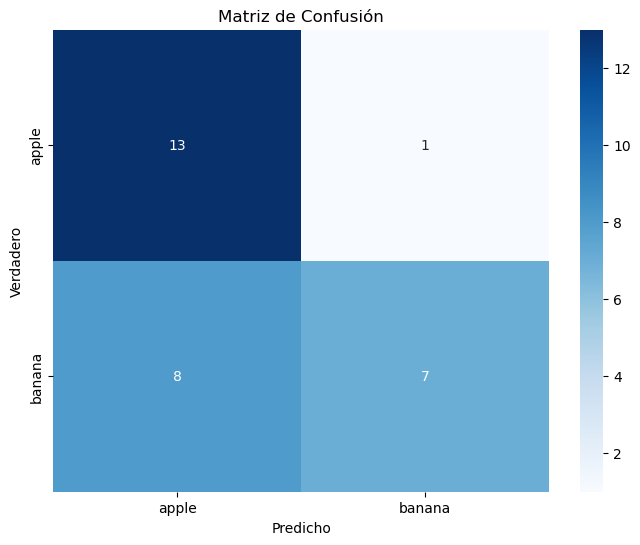


Matriz de Confusión:
[[13  1]
 [ 8  7]]


In [18]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)

# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clases, yticklabels=clases)
plt.title('Matriz de Confusión')
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.show()

print("\nMatriz de Confusión:")
print(cm)

### 11. Reporte de clasificación detallado

In [19]:
# Generar reporte de clasificación
print("Reporte de Clasificación:")
print("="*60)
report = classification_report(y_test, y_test_pred, target_names=clases)
print(report)

Reporte de Clasificación:
              precision    recall  f1-score   support

       apple       0.62      0.93      0.74        14
      banana       0.88      0.47      0.61        15

    accuracy                           0.69        29
   macro avg       0.75      0.70      0.68        29
weighted avg       0.75      0.69      0.67        29



### 12. Visualizar ejemplos de predicciones

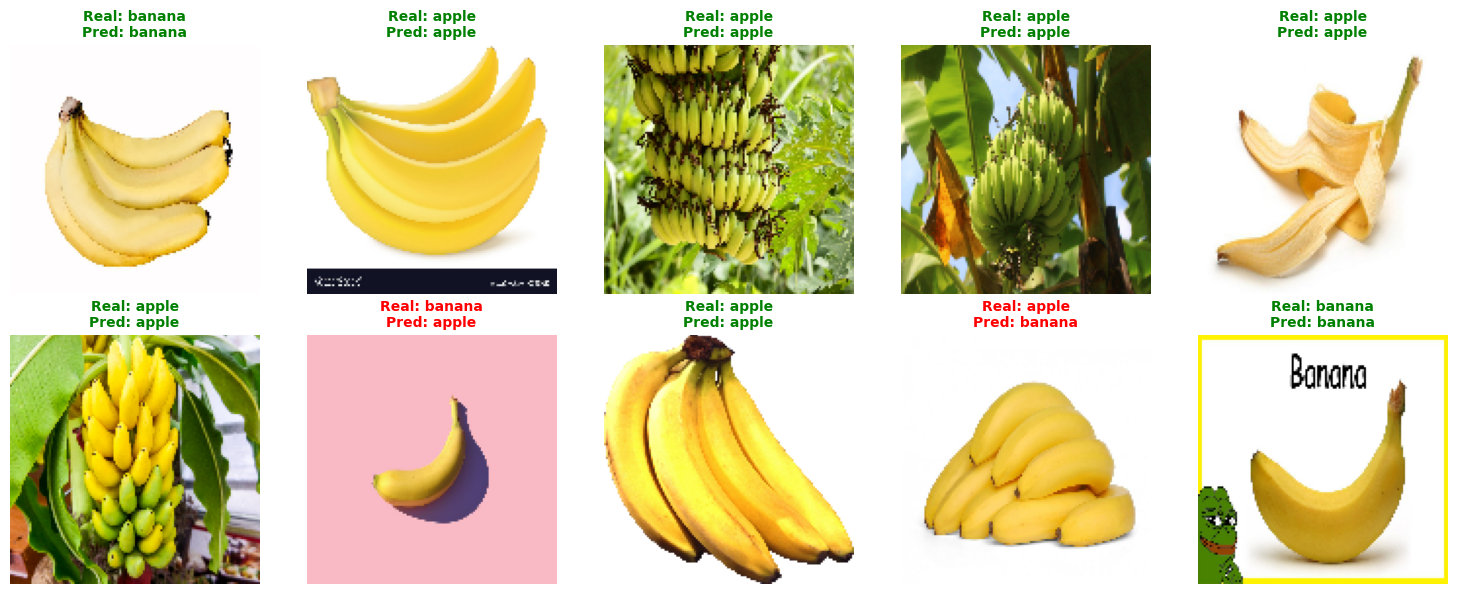

In [20]:
# Obtener índices del conjunto de prueba
indices_test = np.where(np.isin(np.arange(len(y_etiquetas)), 
                                np.arange(len(X_features))[len(X_train):]))[0]

# Seleccionar algunas predicciones aleatorias para visualizar
num_ejemplos = min(10, len(X_test))
indices_random = np.random.choice(len(X_test), num_ejemplos, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, idx in enumerate(indices_random):
    # Obtener la imagen original
    img_idx = len(X_train) + idx
    img = X_imagenes[img_idx]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Predicción y etiqueta verdadera
    pred = y_test_pred[idx]
    true = y_test[idx]
    
    # Visualizar
    axes[i].imshow(img_rgb)
    axes[i].axis('off')
    
    color = 'green' if pred == true else 'red'
    axes[i].set_title(f'Real: {clases[true]}\nPred: {clases[pred]}', 
                      color=color, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 13. Probar con diferentes valores de k

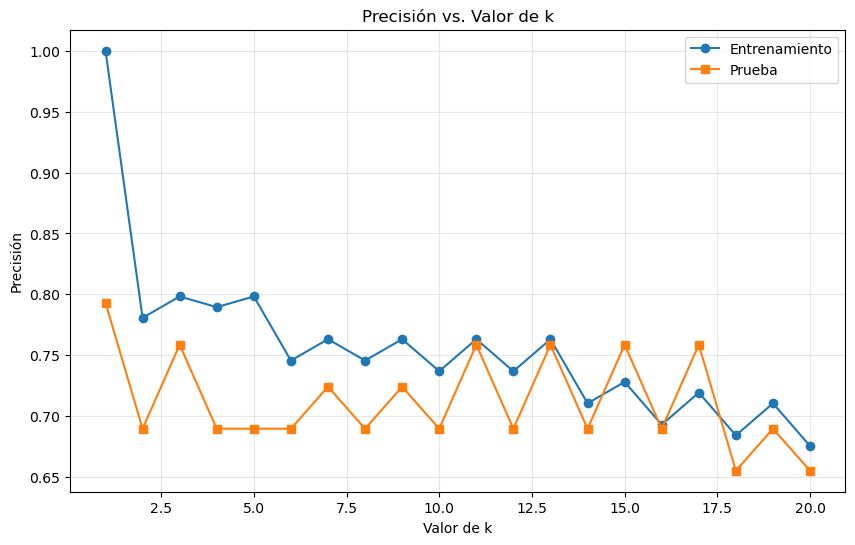


Mejor valor de k: 1
Mejor precisión en prueba: 79.31%


In [22]:
# Probar diferentes valores de k
k_values = range(1, 21)
train_scores = []
test_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    
    train_scores.append(knn_temp.score(X_train, y_train))
    test_scores.append(knn_temp.score(X_test, y_test))

# Visualizar resultados
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, label='Entrenamiento', marker='o')
plt.plot(k_values, test_scores, label='Prueba', marker='s')
plt.xlabel('Valor de k')
plt.ylabel('Precisión')
plt.title('Precisión vs. Valor de k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Encontrar el mejor k
best_k = k_values[np.argmax(test_scores)]
best_accuracy = max(test_scores)
print(f"\nMejor valor de k: {best_k}")
print(f"Mejor precisión en prueba: {best_accuracy*100:.2f}%")

### 14. Resultados finales

In [23]:
# Entrenar con el mejor k encontrado
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# Predicciones finales
y_final_pred = knn_final.predict(X_test)
final_accuracy = accuracy_score(y_test, y_final_pred)

print("="*60)
print("RESULTADOS FINALES DEL CLASIFICADOR")
print("="*60)
print(f"Clases: {clases}")
print(f"Total de imágenes: {len(X_features)}")
print(f"Imágenes de entrenamiento: {len(X_train)}")
print(f"Imágenes de prueba: {len(X_test)}")
print(f"Características por imagen (HOG): {X_features.shape[1]}")
print(f"Mejor valor de k: {best_k}")
print(f"\nPRECISIÓN FINAL: {final_accuracy*100:.2f}%")
print("="*60)

if final_accuracy >= 0.70:
    print("✓ El clasificador supera el 70% de precisión requerido!")
else:
    print("✗ El clasificador no alcanza el 70% de precisión.")
    print("  Sugerencias: agregar más clases, ajustar parámetros, o probar otras características.")

RESULTADOS FINALES DEL CLASIFICADOR
Clases: ['apple', 'banana']
Total de imágenes: 143
Imágenes de entrenamiento: 114
Imágenes de prueba: 29
Características por imagen (HOG): 8100
Mejor valor de k: 1

PRECISIÓN FINAL: 79.31%
✓ El clasificador supera el 70% de precisión requerido!
